In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score

                      run_id  pssm_weight  decay_factor  init_perc_rank  \
0  pw0.91_df0.608_pr9.80_ni3     0.914806      0.608443        9.804038   
1  pw0.91_df0.608_pr9.80_ni3     0.914806      0.608443        9.804038   
2  pw0.91_df0.608_pr9.80_ni3     0.914806      0.608443        9.804038   
3  pw0.94_df0.649_pr2.06_ni4     0.937075      0.649305        2.057386   
4  pw0.94_df0.649_pr2.06_ni4     0.937075      0.649305        2.057386   

   n_iterations  mean_auc01     peptide     auc01  
0             3    0.761211   LLWNGPMAV  0.790395  
1             3    0.761211  ELAGIGILTV  0.800913  
2             3    0.761211   GILGFVFTL  0.692324  
3             4    0.737153   LLWNGPMAV  0.790898  
4             4    0.737153  ELAGIGILTV  0.739559  


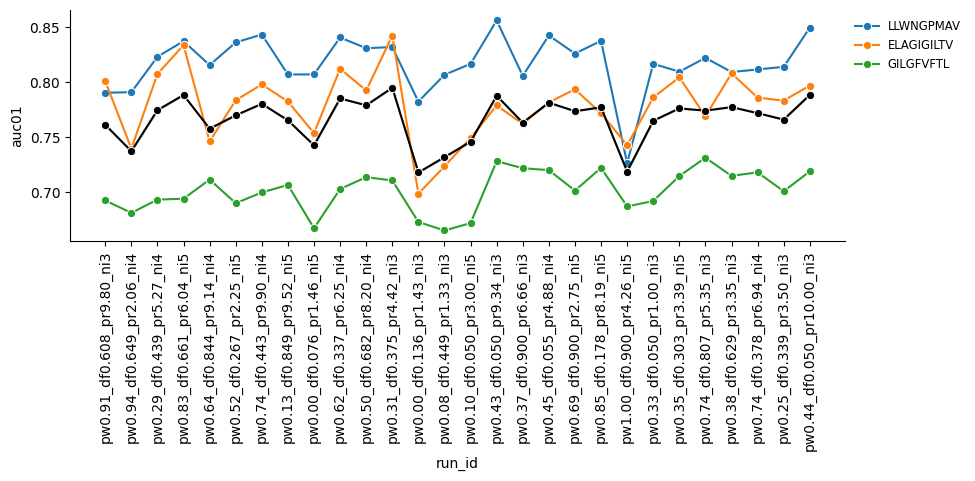

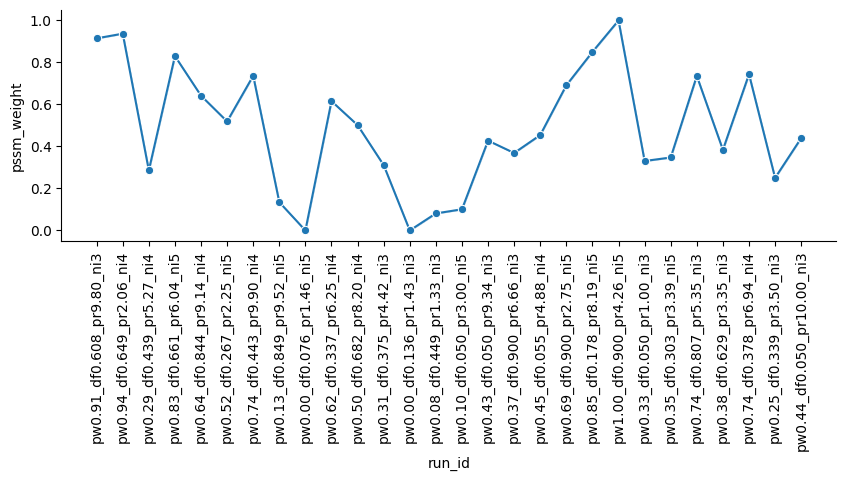

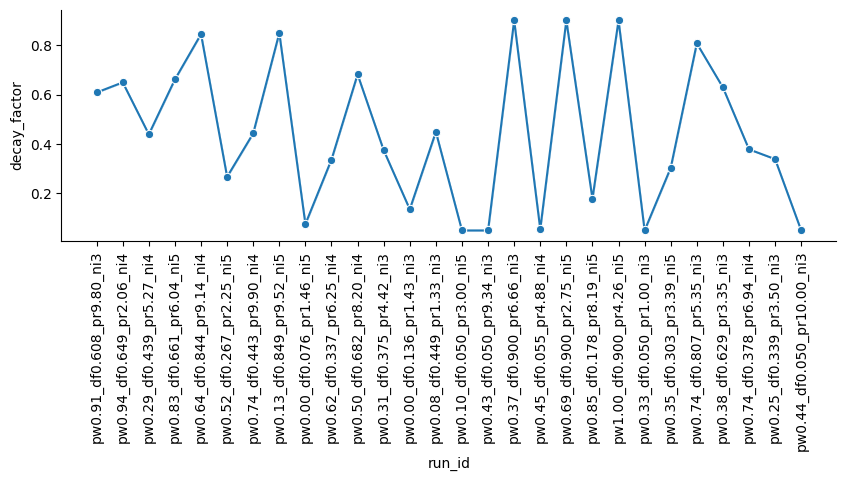

In [43]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')

print(df.head())
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='auc01', hue='peptide', ax=ax, marker='o')
sns.lineplot(df, x='run_id', y='mean_auc01', ax=ax, marker='o', color='black')
ax.tick_params(axis='x', rotation=90)

ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='pssm_weight', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='decay_factor', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()



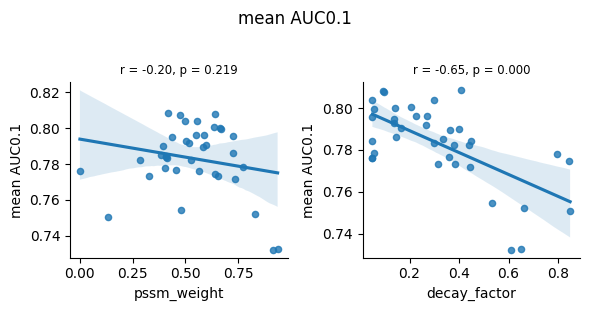

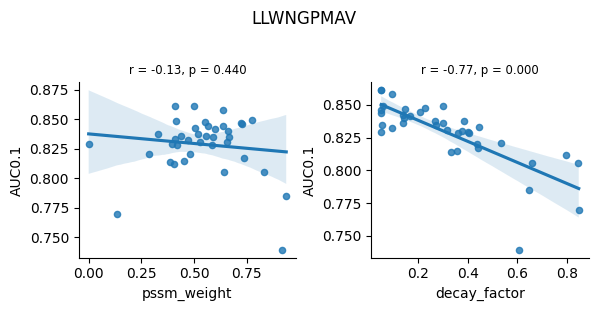

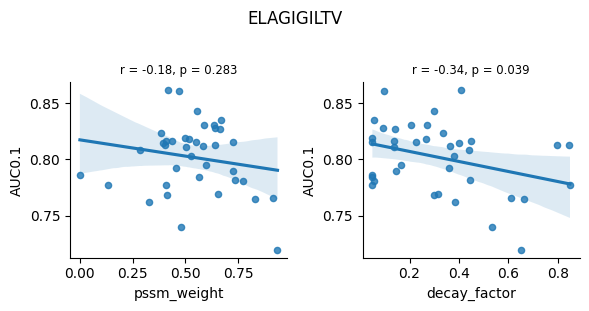

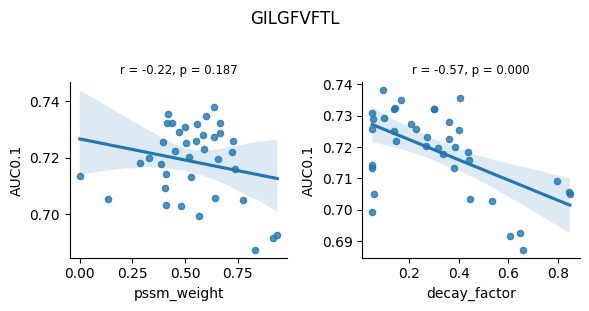

In [40]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')
df = df[df['step'] == 3]

params = ['pssm_weight', 'decay_factor']
peptides = df['peptide'].unique()

# mean auc01 correlations
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, param in zip(axes, params):
    df_corr = df[['mean_auc01', param]].drop_duplicates()
    r, p = stats.pearsonr(df_corr[param], df_corr['mean_auc01'])
    sns.regplot(df_corr, x=param, y='mean_auc01', ax=ax, scatter_kws={'s': 20})
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
    ax.set_xlabel(param)
    ax.set_ylabel('mean AUC0.1')
plt.suptitle('mean AUC0.1', y=1.02)
plt.tight_layout()
sns.despine()

# per-peptide correlations
for peptide in peptides:
    df_pep = df[df['peptide'] == peptide]
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, param in zip(axes, params):
        r, p = stats.pearsonr(df_pep[param], df_pep['auc01'])
        sns.regplot(df_pep, x=param, y='auc01', ax=ax, scatter_kws={'s': 20})
        ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
        ax.set_xlabel(param)
        ax.set_ylabel('AUC0.1')
    plt.suptitle(peptide, y=1.02)
    plt.tight_layout()
    sns.despine()

# ?

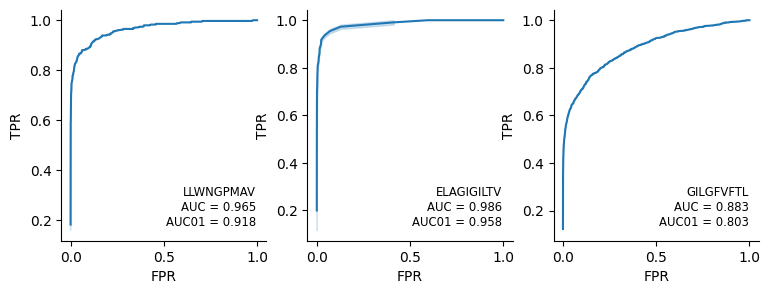

In [28]:
peptides = ['LLWNGPMAV', 'ELAGIGILTV', 'GILGFVFTL']

fig, axes = plt.subplots(1,3,figsize=(9,3))

for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]
    df = pd.read_csv(f'test_TEMPO_validation_{peptide}/validation_pred.csv')

    y_true = df['Label'].values
    y_scores = df['score'].values

    # ROC + metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_full = roc_auc_score(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

    # plot
    sns.lineplot(x=fpr, y=tpr, ax=ax)

    label = f"{peptide}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"

    ax.text(
        0.95, 0.05,
        label,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize='small'
    )

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    sns.despine()
